<a href="https://colab.research.google.com/github/elsabilanurbaity/-OLYMATH-/blob/main/OLYMATH_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏆 OLYMATH – Training Model Seleksi Olimpiade Matematika

**Notebook ini berisi langkah-langkah:**
1. Install library yang dibutuhkan
2. Upload & load dataset
3. Eksplorasi & visualisasi data
4. Labeling & training model Random Forest
5. Evaluasi model
6. Simpan model ke Google Drive

## 📦 1. Install & Import Library

In [1]:
# Install library yang diperlukan
!pip install scikit-learn pandas openpyxl matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## 📂 2. Upload & Load Dataset

In [2]:
from google.colab import files
import io

print('📂 Silakan upload file dataset.xlsx kamu:')
uploaded = files.upload()

# Ambil file pertama yang diupload
filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))

print(f'✅ Dataset berhasil dimuat: {df.shape[0]:,} baris, {df.shape[1]} kolom')
df.head()

📂 Silakan upload file dataset.xlsx kamu:


Saving dataset.xlsx to dataset.xlsx
✅ Dataset berhasil dimuat: 30,000 baris, 6 kolom


,NUM_ALJ,NUM_GEO,NUM_BIL,NUM_DAT,NUM_L3,LIT
0,57.6622,74.4989,96.6700,79.1665,80.0000,100.0000
1,35.6578,29.1565,48.4937,48.3270,53.4947,50.1607
2,98.0036,98.3370,96.6700,87.5015,100.0000,100.0000
3,100.0000,74.8323,53.1613,74.6656,82.6672,71.6650
4,73.3320,93.1693,60.9962,26.1559,72.1651,53.3280


## 🔍 3. Eksplorasi Data (EDA)

In [3]:
# Info dataset
print('=== INFO DATASET ===')
print(df.info())
print('\n=== STATISTIK DESKRIPTIF ===')
print(df.describe().round(2))
print(f'\n=== MISSING VALUES ===')
print(df.isnull().sum())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   NUM_ALJ  29762 non-null  float64
 1   NUM_GEO  29762 non-null  float64
 2   NUM_BIL  29762 non-null  float64
 3   NUM_DAT  29765 non-null  float64
 4   NUM_L3   29762 non-null  float64
 5   LIT      29797 non-null  float64
dtypes: float64(6)
memory usage: 1.4 MB
None

=== STATISTIK DESKRIPTIF ===
        NUM_ALJ   NUM_GEO   NUM_BIL   NUM_DAT    NUM_L3       LIT
count  29762.00  29762.00  29762.00  29765.00  29762.00  29797.00
mean      63.43     63.30     61.09     63.31     65.53     72.05
std       19.21     22.34     20.90     21.40     18.95     21.53
min        9.82      4.65      0.82      9.49     28.99      0.00
25%       57.00     48.16     47.66     47.83     54.33     58.66
50%       67.33     65.66     62.83     63.33     65.50     76.00
75%       76.00     79.83     

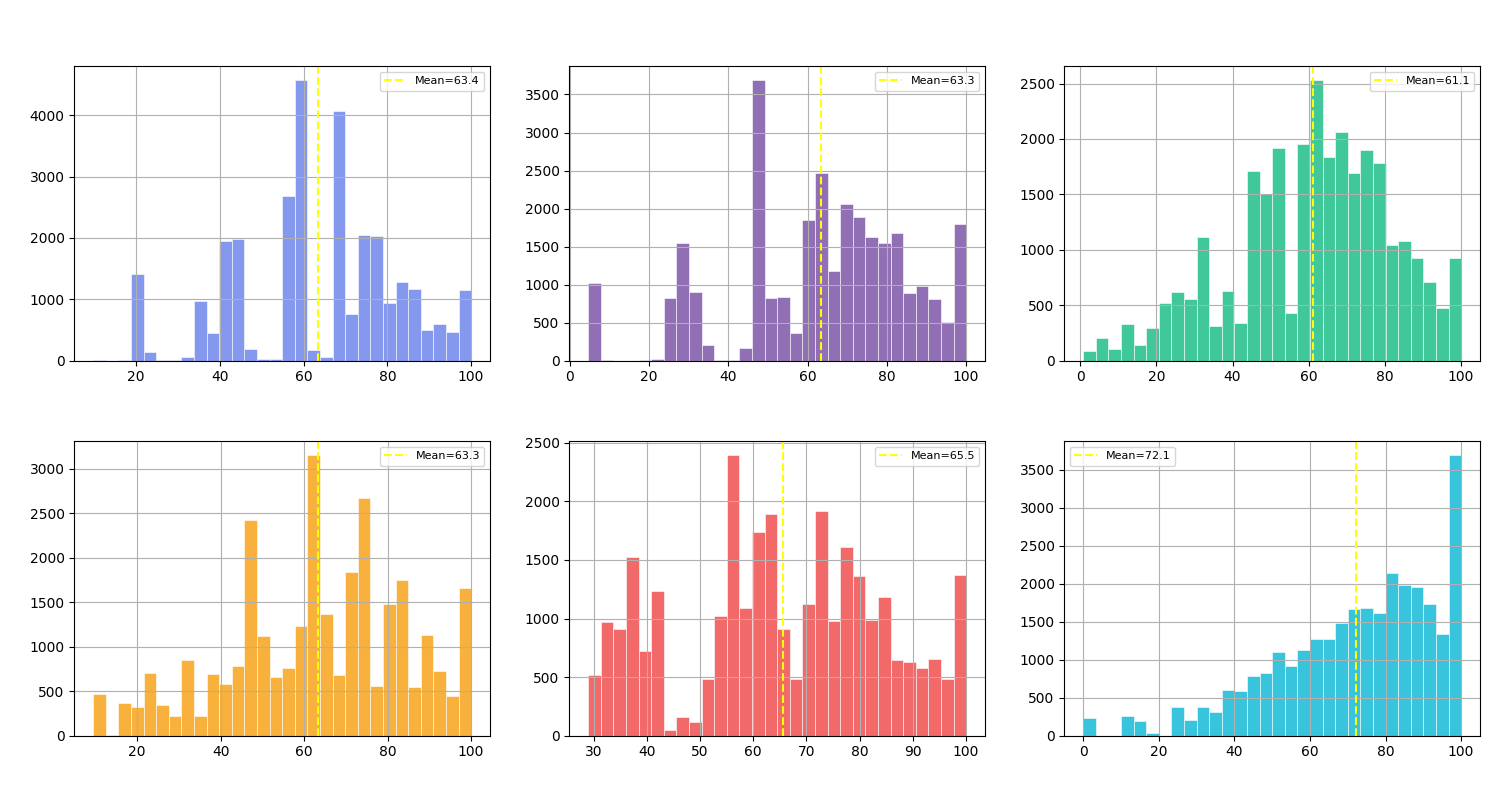

✅ Grafik disimpan!


In [4]:
# Visualisasi distribusi nilai
features = ['NUM_ALJ', 'NUM_GEO', 'NUM_BIL', 'NUM_DAT', 'NUM_L3', 'LIT']
feature_labels = {
    'NUM_ALJ': 'Numerasi Aljabar',
    'NUM_GEO': 'Numerasi Geometri',
    'NUM_BIL': 'Numerasi Bilangan',
    'NUM_DAT': 'Data & Ketidakpastian',
    'NUM_L3':  'Kemampuan Menalar',
    'LIT':     'Literasi Matematika',
}

plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribusi Nilai Kompetensi Siswa', fontsize=16, fontweight='bold', color='white')
colors = ['#667eea', '#764ba2', '#10b981', '#f59e0b', '#ef4444', '#06b6d4']

for ax, feat, color in zip(axes.flat, features, colors):
    df[feat].dropna().hist(ax=ax, bins=30, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.set_title(feature_labels[feat], fontweight='bold', color='white')
    ax.set_xlabel('Skor', color='white')
    ax.set_ylabel('Frekuensi', color='white')
    ax.axvline(df[feat].mean(), color='yellow', linestyle='--', linewidth=1.5, label=f'Mean={df[feat].mean():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/distribusi_nilai.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan!')

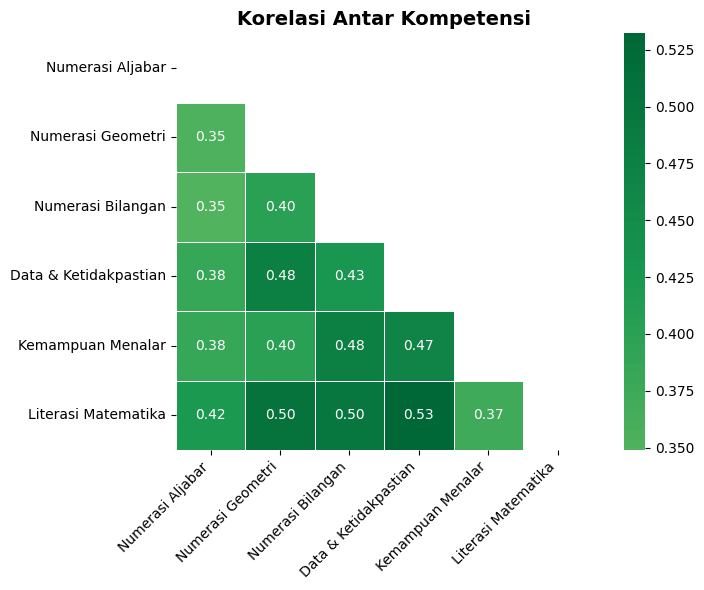

In [5]:
# Heatmap korelasi
plt.figure(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, square=True, linewidths=0.5,
            xticklabels=[feature_labels[f] for f in features],
            yticklabels=[feature_labels[f] for f in features])
plt.title('Korelasi Antar Kompetensi', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/korelasi.png', dpi=120, bbox_inches='tight')
plt.show()

## 🏷️ 4. Labeling Data

In [6]:
df = df.dropna()

def label_siswa(row):
    """
    Kriteria labeling berdasarkan logika pedagogis:
    - Siap Olimpiade: rata-rata >= 80 AND semua nilai >= 40 (konsisten unggul)
    - Potensial     : rata-rata >= 65 AND nilai min >= 35 (ada potensi)
    - Tidak Siap    : di bawah kriteria potensial
    """
    skor = row[features].values.astype(float)
    rata = np.mean(skor)
    min_skor = np.min(skor)

    if rata >= 80 and min_skor >= 40:
        return 'Siap Olimpiade'
    elif rata >= 65 and min_skor >= 35:
        return 'Potensial'
    else:
        return 'Tidak Siap'

df['label'] = df.apply(label_siswa, axis=1)

print('=== DISTRIBUSI LABEL ===')
label_counts = df['label'].value_counts()
print(label_counts)
print(f'\nProporsi:')
print((label_counts / len(df) * 100).round(1))

=== DISTRIBUSI LABEL ===
label
Tidak Siap        15208
Potensial          9383
Siap Olimpiade     4968
Name: count, dtype: int64

Proporsi:
label
Tidak Siap        51.4
Potensial         31.7
Siap Olimpiade    16.8
Name: count, dtype: float64


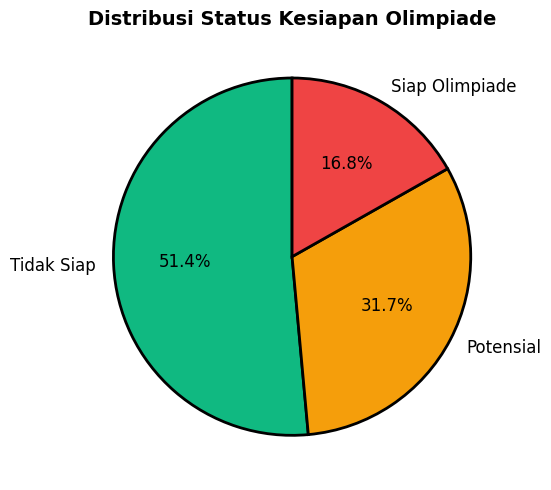

In [7]:
# Visualisasi distribusi label
colors_pie = ['#10b981', '#f59e0b', '#ef4444']
plt.figure(figsize=(7, 5))
label_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors_pie,
                  startangle=90, textprops={'fontsize': 12, 'color': 'black'},
                  wedgeprops={'edgecolor': 'black', 'linewidth': 2})
plt.title('Distribusi Status Kesiapan Olimpiade', fontsize=14, fontweight='bold', color='black')
plt.ylabel('')
plt.tight_layout()
plt.savefig('/content/distribusi_label.png', dpi=120, bbox_inches='tight')
plt.show()

## 🤖 5. Training Model Random Forest

In [8]:
X = df[features]
y = df['label']

# Scaling fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data training: {X_train.shape[0]:,} sampel')
print(f'Data testing : {X_test.shape[0]:,} sampel')

# Training Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

print('\n✅ Model berhasil dilatih!')

Data training: 23,647 sampel
Data testing : 5,912 sampel

✅ Model berhasil dilatih!


## 📊 6. Evaluasi Model

In [9]:
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'=== AKURASI: {acc:.4f} ({acc*100:.2f}%) ===')
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred))

# Cross-validation
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'\n=== CROSS-VALIDATION (5-fold) ===')
print(f'Scores: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

=== AKURASI: 0.9540 (95.40%) ===

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

     Potensial       0.90      0.96      0.93      1877
Siap Olimpiade       0.96      0.93      0.94       993
    Tidak Siap       0.99      0.96      0.97      3042

      accuracy                           0.95      5912
     macro avg       0.95      0.95      0.95      5912
  weighted avg       0.96      0.95      0.95      5912


=== CROSS-VALIDATION (5-fold) ===
Scores: [0.9577 0.9641 0.9643 0.9312 0.9377]
Mean: 0.9510 ± 0.0139


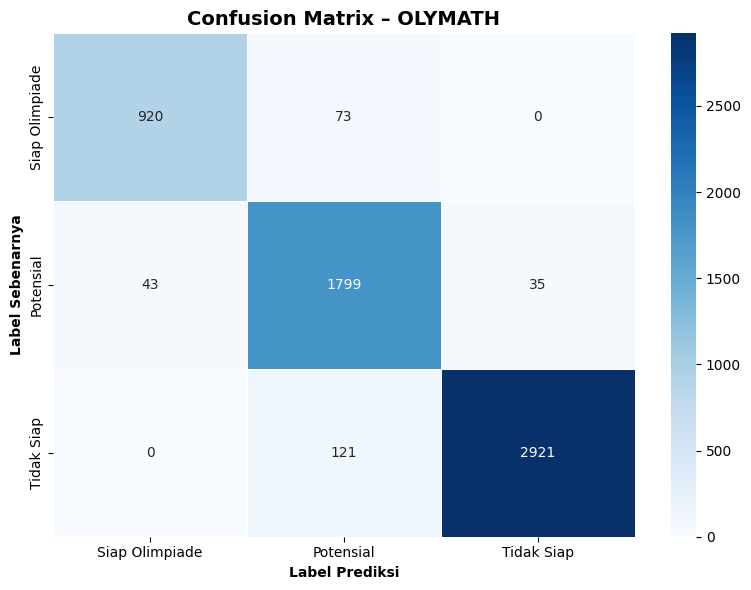

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Siap Olimpiade', 'Potensial', 'Tidak Siap'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Siap Olimpiade', 'Potensial', 'Tidak Siap'],
            yticklabels=['Siap Olimpiade', 'Potensial', 'Tidak Siap'],
            linewidths=0.5)
plt.title('Confusion Matrix – OLYMATH', fontsize=14, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontweight='bold')
plt.xlabel('Label Prediksi', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

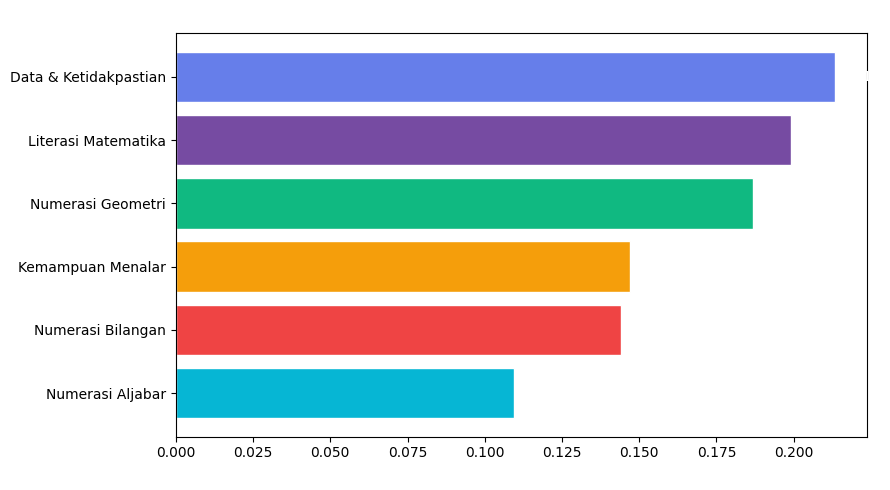

In [11]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=[feature_labels[f] for f in features])
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(importances.index, importances.values, color=colors[::-1], edgecolor='white')
plt.title('Feature Importance – Kontribusi Tiap Kompetensi', fontsize=14, fontweight='bold', color='white')
plt.xlabel('Importance Score', color='white')
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left', fontsize=10, color='white')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 💾 7. Simpan dan Download Model

In [16]:
# Simpan & Download Model
import pickle
from google.colab import files

# Simpan model ke /content dulu
model_data = {
    'model': rf,
    'scaler': scaler,
    'features': features,
    'classes': list(rf.classes_),
}

model_path = '/content/model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f'Model berhasil disimpan!')
print(f'   Ukuran file: {os.path.getsize(model_path)/1024:.1f} KB')
print(f'\n Ringkasan Model:')
print(f'   - Algoritma   : Random Forest Classifier')
print(f'   - n_estimators: {rf.n_estimators}')
print(f'   - max_depth   : {rf.max_depth}')
print(f'   - Akurasi     : {acc*100:.2f}%')
print(f'   - Kelas       : {list(rf.classes_)}')

# Langsung trigger download ke browser
files.download(model_path)
print('\n Download model.pkl dimulai...')

Model berhasil disimpan!
   Ukuran file: 9065.4 KB

 Ringkasan Model:
   - Algoritma   : Random Forest Classifier
   - n_estimators: 100
   - max_depth   : 10
   - Akurasi     : 95.40%
   - Kelas       : ['Potensial', 'Siap Olimpiade', 'Tidak Siap']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Download model.pkl dimulai...


In [17]:
# Download semua output sekaligus dalam 1 zip
import zipfile, os
from google.colab import files

zip_path = '/content/OLYMATH_output.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    zf.write('/content/model.pkl', 'model.pkl')
    for img in ['distribusi_nilai.png', 'korelasi.png', 'distribusi_label.png',
                'confusion_matrix.png', 'feature_importance.png']:
        src = f'/content/{img}'
        if os.path.exists(src):
            zf.write(src, img)

files.download(zip_path)
print('OLYMATH_output.zip berhasil didownload!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

OLYMATH_output.zip berhasil didownload!
